プレーンなやり方:

有理関数の次数: (3,2)

初期活性化関数: 指定なし

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 0.020298


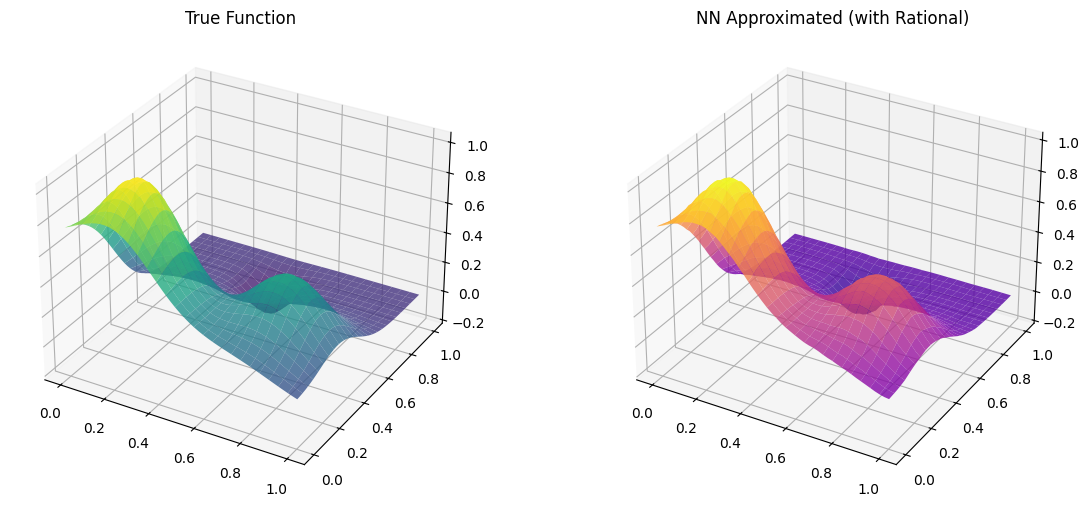

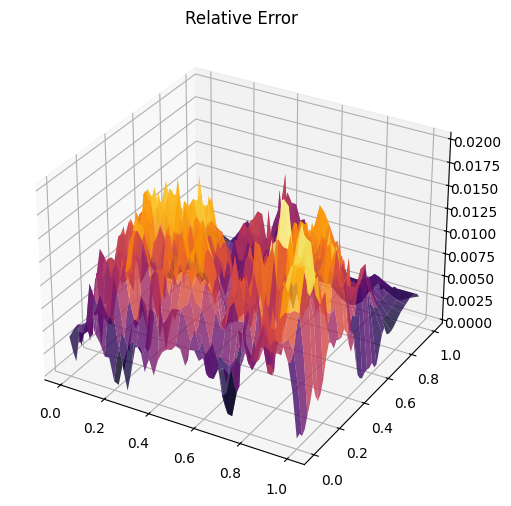

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

class RationalActivation(nn.Module):
    def __init__(self):
        super().__init__()
        # 係数を3次まで拡張
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0, 0.0])) # a0, a1, a2, a3
        self.b = nn.Parameter(torch.tensor([-4.0, 0.0])) # b1, b2
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1]*x + self.a[2]*(x**2) + self.a[3]*(x**3)
        denominator = 1.0 + torch.abs(self.b[0]*x + self.b[1]*(x**2))
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (Rational Activation を使用)
class Rational_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

Nakatsukasa方式:

有理関数の次数: (3,2)型

初期活性化関数: ReLUの有理関数近似

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 0.012798


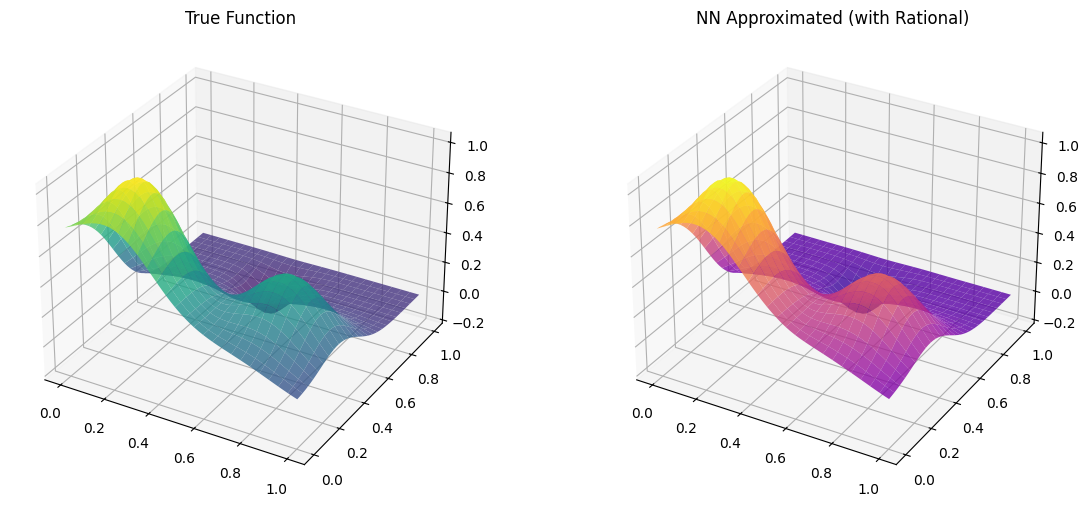

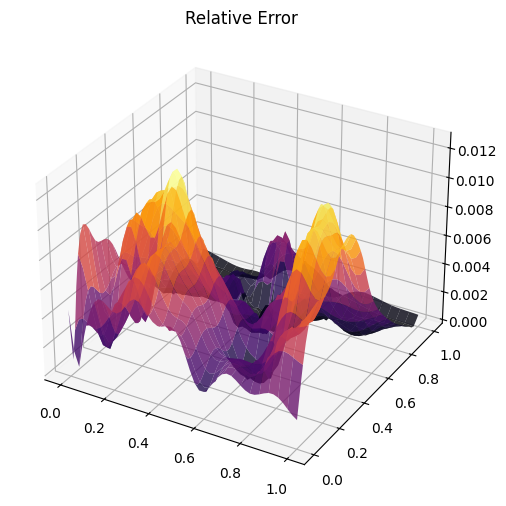

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# ==========================================
# 活性化関数とモデル定義
# ==========================================
class RationalActivation(nn.Module):
    def __init__(self, mode='nakatsukasa'):
        super().__init__()
        self.mode = mode
        
        if mode == 'nakatsukasa':
            # Nakatsukasa方式: (3, 2)型
            # ReLUの挙動に近づけるための初期化
            self.a = nn.Parameter(torch.tensor([0.0, 0.5, 0.5, 0.0], dtype=torch.float32))
            self.b = nn.Parameter(torch.tensor([0.0, 1.0], dtype=torch.float32))
            
        elif mode == 'molina':
            # Molina方式: (5, 4)型
            # Leaky ReLU (alpha=0.01) をパデ近似する厳密な初期化係数
            self.a = nn.Parameter(torch.tensor([0.02979246, 0.61837738, 2.32335207, 3.05202660, 1.48548002, 0.25103717], dtype=torch.float32))
            self.b = nn.Parameter(torch.tensor([1.14201226, 4.39322834, 0.87154450, 0.34720652], dtype=torch.float32))
            
        else:
            raise ValueError("mode must be 'nakatsukasa' or 'molina'")

    def forward(self, x):
        # 分子 P(x) の計算 (a_0 + a_1*x + a_2*x^2 + ...)
        numerator = self.a[0]
        for i in range(1, len(self.a)):
            numerator = numerator + self.a[i] * (x ** i)
        
        # 分母 Q(x) の変数部分の計算 (b_1*x + b_2*x^2 + ...)
        denominator_inner = 0.0
        for i in range(len(self.b)):
            denominator_inner = denominator_inner + self.b[i] * (x ** (i + 1))
            
        # 安定性のための絶対値バリア (MolinaのSafe PAU構造)[cite: 5]
        denominator = 1.0 + torch.abs(denominator_inner)
        
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (モードを引数で受け取るように変更)
class Rational_MLP(nn.Module):
    def __init__(self, activation_mode='nakatsukasa'):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 実行時に好きなモードを選択 ('nakatsukasa' または 'molina')
mode_selection = 'nakatsukasa' 
model = Rational_MLP(activation_mode=mode_selection)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

Molina方式

有理関数の次数: (5,4)

初期活性化関数: Leaky ReLUの有理関数近似

Rational activationモデルの訓練を開始します...
訓練が完了しました。
Max Relative Error: 0.024587


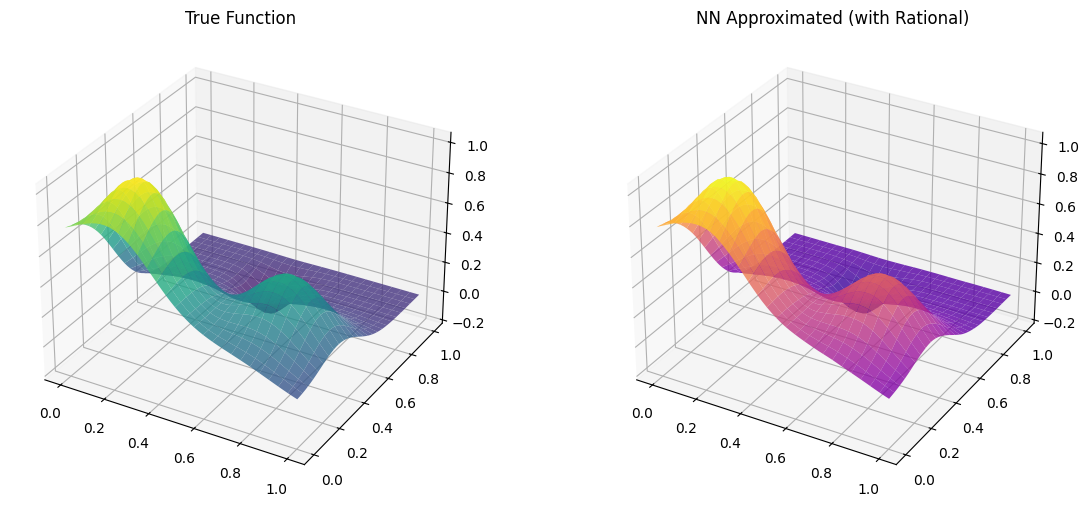

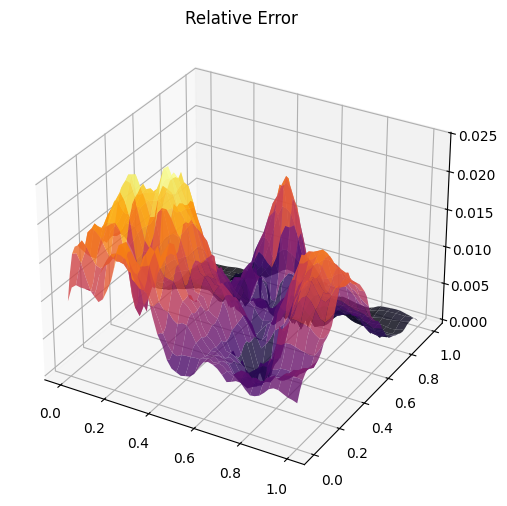

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# コードの最初に挿入
torch.manual_seed(42)
np.random.seed(42)

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# ==========================================
# 活性化関数とモデル定義
# ==========================================
class RationalActivation(nn.Module):
    def __init__(self, mode='nakatsukasa'):
        super().__init__()
        self.mode = mode
        
        if mode == 'nakatsukasa':
            # Nakatsukasa方式: (3, 2)型
            # ReLUの挙動に近づけるための初期化
            self.a = nn.Parameter(torch.tensor([0.0, 0.5, 0.5, 0.0], dtype=torch.float32))
            self.b = nn.Parameter(torch.tensor([0.0, 1.0], dtype=torch.float32))
            
        elif mode == 'molina':
            # Molina方式: (5, 4)型
            # Leaky ReLU (alpha=0.01) をパデ近似する厳密な初期化係数
            self.a = nn.Parameter(torch.tensor([0.02979246, 0.61837738, 2.32335207, 3.05202660, 1.48548002, 0.25103717], dtype=torch.float32))
            self.b = nn.Parameter(torch.tensor([1.14201226, 4.39322834, 0.87154450, 0.34720652], dtype=torch.float32))
            
        else:
            raise ValueError("mode must be 'nakatsukasa' or 'molina'")

    def forward(self, x):
        # 分子 P(x) の計算 (a_0 + a_1*x + a_2*x^2 + ...)
        numerator = self.a[0]
        for i in range(1, len(self.a)):
            numerator = numerator + self.a[i] * (x ** i)
        
        # 分母 Q(x) の変数部分の計算 (b_1*x + b_2*x^2 + ...)
        denominator_inner = 0.0
        for i in range(len(self.b)):
            denominator_inner = denominator_inner + self.b[i] * (x ** (i + 1))
            
        # 安定性のための絶対値バリア (MolinaのSafe PAU構造)[cite: 5]
        denominator = 1.0 + torch.abs(denominator_inner)
        
        return numerator / (denominator + 1e-6)

# 3. モデル定義 (モードを引数で受け取るように変更)
class Rational_MLP(nn.Module):
    def __init__(self, activation_mode='nakatsukasa'):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 64),
            RationalActivation(mode=activation_mode),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 実行時に好きなモードを選択 ('nakatsukasa' または 'molina')
mode_selection = 'molina' 
model = Rational_MLP(activation_mode=mode_selection)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練
print("Rational activationモデルの訓練を開始します...")
for epoch in range(3000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()